In [93]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import SplineTransformer, PolynomialFeatures

from pygam import LogisticGAM, s, l

# Data Preparation

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [ ]:
df = pd.read_csv("data/datav3.csv")
df.head()

,customer_id,observation_month,branch_id,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,device_type,region,app_theme,education_level,marketing_channel,campaign_code,noise_feature_1,noise_feature_2,noise_feature_3,purchased
0,CUST01723,2026-06-01,B24,57,4144.46,49861.80,8,25,18.74,9.01,3,1,16.1,2,11,2,1,5,17,Desktop,West,Dark,Bachelor,Organic,CMP60,-0.3758,0.7415,1,0
1,CUST03090,2025-11-01,B05,39,3313.13,39964.60,7,27,12.38,7.64,1,1,6.6,0,11,6,1,7,8,Mobile,Central,System,Bachelor,Email,CMP02,-0.6708,0.5766,1,0
2,CUST04684,2026-01-01,B13,51,4965.57,58703.65,3,15,8.97,15.84,3,0,55.0,0,3,5,1,4,8,Mobile,North,Light,Master,Organic,CMP04,0.2868,-0.6751,0,0
3,CUST01687,2025-03-01,B05,56,2045.66,24364.68,7,24,30.73,10.50,0,0,22.8,0,6,8,0,5,8,Mobile,Central,Dark,Bachelor,Social,CMP10,2.1992,0.8292,1,0
4,CUST00535,2025-11-01,B17,31,4355.62,51882.27,10,29,31.40,2.09,0,0,40.1,1,10,4,0,8,8,Desktop,South,Dark,Bachelor,Search,CMP01,-1.2592,-0.1662,1,0


In [ ]:
df.shape

(7519, 29)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7519 entries, 0 to 7518
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               7519 non-null   str    
 1   observation_month         7519 non-null   str    
 2   branch_id                 7519 non-null   str    
 3   age                       7519 non-null   int64  
 4   monthly_income            7519 non-null   float64
 5   annual_income             7519 non-null   float64
 6   website_visits_30d        7519 non-null   int64  
 7   website_visits_90d        7519 non-null   int64  
 8   session_minutes           7519 non-null   float64
 9   discount_pct              7519 non-null   float64
 10  support_tickets_30d       7519 non-null   int64  
 11  premium_member            7519 non-null   int64  
 12  days_since_last_purchase  7519 non-null   float64
 13  cart_items                7519 non-null   int64  
 14  email_opens_30d    

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(35)

## Data Transformation

### Dummy Encoding

In [ ]:
cate_df = df[['device_type', 'region', 'app_theme', 'marketing_channel']]
cate_df.head()

,device_type,region,app_theme,marketing_channel
0,Desktop,West,Dark,Organic
1,Mobile,Central,System,Email
2,Mobile,North,Light,Organic
3,Mobile,Central,Dark,Social
4,Desktop,South,Dark,Search


In [ ]:
dumpy_encoded_df = pd.get_dummies(
    cate_df,
    drop_first=True,
    dtype=int
)
dumpy_encoded_df.head()

,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,marketing_channel_Email,marketing_channel_Organic,marketing_channel_Partner_Rare,marketing_channel_Referral,marketing_channel_Search,marketing_channel_Social
0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
1,1,0,0,0,0,0,0,1,1,0,0,0,0,0
2,1,0,0,1,0,0,1,0,0,1,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,1,0,0,0,0,0,0,0,1,0


In [ ]:
df = pd.concat([df, dumpy_encoded_df], axis=1)
df.head()

,customer_id,observation_month,branch_id,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,device_type,region,app_theme,education_level,marketing_channel,campaign_code,noise_feature_1,noise_feature_2,noise_feature_3,purchased,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,marketing_channel_Email,marketing_channel_Organic,marketing_channel_Partner_Rare,marketing_channel_Referral,marketing_channel_Search,marketing_channel_Social
0,CUST01723,2026-06-01,B24,57,4144.46,49861.80,8,25,18.74,9.01,3,1,16.1,2,11,2,1,5,17,Desktop,West,Dark,Bachelor,Organic,CMP60,-0.3758,0.7415,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
1,CUST03090,2025-11-01,B05,39,3313.13,39964.60,7,27,12.38,7.64,1,1,6.6,0,11,6,1,7,8,Mobile,Central,System,Bachelor,Email,CMP02,-0.6708,0.5766,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0
2,CUST04684,2026-01-01,B13,51,4965.57,58703.65,3,15,8.97,15.84,3,0,55.0,0,3,5,1,4,8,Mobile,North,Light,Master,Organic,CMP04,0.2868,-0.6751,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0
3,CUST01687,2025-03-01,B05,56,2045.66,24364.68,7,24,30.73,10.50,0,0,22.8,0,6,8,0,5,8,Mobile,Central,Dark,Bachelor,Social,CMP10,2.1992,0.8292,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
4,CUST00535,2025-11-01,B17,31,4355.62,51882.27,10,29,31.40,2.09,0,0,40.1,1,10,4,0,8,8,Desktop,South,Dark,Bachelor,Search,CMP01,-1.2592,-0.1662,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0


### Ordinary Encoding

In [ ]:
df.head()

,customer_id,observation_month,branch_id,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,device_type,region,app_theme,education_level,marketing_channel,campaign_code,noise_feature_1,noise_feature_2,noise_feature_3,purchased,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,marketing_channel_Email,marketing_channel_Organic,marketing_channel_Partner_Rare,marketing_channel_Referral,marketing_channel_Search,marketing_channel_Social
0,CUST01723,2026-06-01,B24,57,4144.46,49861.80,8,25,18.74,9.01,3,1,16.1,2,11,2,1,5,17,Desktop,West,Dark,Bachelor,Organic,CMP60,-0.3758,0.7415,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
1,CUST03090,2025-11-01,B05,39,3313.13,39964.60,7,27,12.38,7.64,1,1,6.6,0,11,6,1,7,8,Mobile,Central,System,Bachelor,Email,CMP02,-0.6708,0.5766,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0
2,CUST04684,2026-01-01,B13,51,4965.57,58703.65,3,15,8.97,15.84,3,0,55.0,0,3,5,1,4,8,Mobile,North,Light,Master,Organic,CMP04,0.2868,-0.6751,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0
3,CUST01687,2025-03-01,B05,56,2045.66,24364.68,7,24,30.73,10.50,0,0,22.8,0,6,8,0,5,8,Mobile,Central,Dark,Bachelor,Social,CMP10,2.1992,0.8292,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
4,CUST00535,2025-11-01,B17,31,4355.62,51882.27,10,29,31.40,2.09,0,0,40.1,1,10,4,0,8,8,Desktop,South,Dark,Bachelor,Search,CMP01,-1.2592,-0.1662,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0


In [ ]:
df['education_level'].value_counts()

education_level
Bachelor       3140
High School    2090
Master         1771
PhD             518
Name: count, dtype: int64

In [ ]:
education_level_mapping = {
    "High School":1,
    "Bachelor":2,
    "Master":3,
    "PhD":4
}
df['education_level'] = df['education_level'].map(education_level_mapping)
df.head()

,customer_id,observation_month,branch_id,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,device_type,region,app_theme,education_level,marketing_channel,campaign_code,noise_feature_1,noise_feature_2,noise_feature_3,purchased,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,marketing_channel_Email,marketing_channel_Organic,marketing_channel_Partner_Rare,marketing_channel_Referral,marketing_channel_Search,marketing_channel_Social
0,CUST01723,2026-06-01,B24,57,4144.46,49861.80,8,25,18.74,9.01,3,1,16.1,2,11,2,1,5,17,Desktop,West,Dark,2,Organic,CMP60,-0.3758,0.7415,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
1,CUST03090,2025-11-01,B05,39,3313.13,39964.60,7,27,12.38,7.64,1,1,6.6,0,11,6,1,7,8,Mobile,Central,System,2,Email,CMP02,-0.6708,0.5766,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0
2,CUST04684,2026-01-01,B13,51,4965.57,58703.65,3,15,8.97,15.84,3,0,55.0,0,3,5,1,4,8,Mobile,North,Light,3,Organic,CMP04,0.2868,-0.6751,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0
3,CUST01687,2025-03-01,B05,56,2045.66,24364.68,7,24,30.73,10.50,0,0,22.8,0,6,8,0,5,8,Mobile,Central,Dark,2,Social,CMP10,2.1992,0.8292,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
4,CUST00535,2025-11-01,B17,31,4355.62,51882.27,10,29,31.40,2.09,0,0,40.1,1,10,4,0,8,8,Desktop,South,Dark,2,Search,CMP01,-1.2592,-0.1662,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0


### Dropping Unnecessary columns

In [ ]:
dropping_columns = ['device_type', 'region', 'app_theme', 'marketing_channel']

df = df.drop(columns=dropping_columns)


In [ ]:
df.head()

,customer_id,observation_month,branch_id,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,education_level,campaign_code,noise_feature_1,noise_feature_2,noise_feature_3,purchased,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,marketing_channel_Email,marketing_channel_Organic,marketing_channel_Partner_Rare,marketing_channel_Referral,marketing_channel_Search,marketing_channel_Social
0,CUST01723,2026-06-01,B24,57,4144.46,49861.80,8,25,18.74,9.01,3,1,16.1,2,11,2,1,5,17,2,CMP60,-0.3758,0.7415,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
1,CUST03090,2025-11-01,B05,39,3313.13,39964.60,7,27,12.38,7.64,1,1,6.6,0,11,6,1,7,8,2,CMP02,-0.6708,0.5766,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0
2,CUST04684,2026-01-01,B13,51,4965.57,58703.65,3,15,8.97,15.84,3,0,55.0,0,3,5,1,4,8,3,CMP04,0.2868,-0.6751,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0
3,CUST01687,2025-03-01,B05,56,2045.66,24364.68,7,24,30.73,10.50,0,0,22.8,0,6,8,0,5,8,2,CMP10,2.1992,0.8292,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
4,CUST00535,2025-11-01,B17,31,4355.62,51882.27,10,29,31.40,2.09,0,0,40.1,1,10,4,0,8,8,2,CMP01,-1.2592,-0.1662,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0


### Timestamp column

Observation-month data is  in timestamp format like '2022-02-08'. We need to convert it into numeric values: How many months have passed since the first date in the dataset. 

In [ ]:
df['observation_month'] = pd.to_datetime(
    df['observation_month']
)

# getting the start date of data 
start_date = df['observation_month'].min() 

# calculating 
df['observation_month'] = (
    (df['observation_month'].dt.year - start_date.year) * 12
    + 
    (df['observation_month'].dt.month - start_date.month)
)
df.head()

,customer_id,observation_month,branch_id,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,education_level,campaign_code,noise_feature_1,noise_feature_2,noise_feature_3,purchased,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,marketing_channel_Email,marketing_channel_Organic,marketing_channel_Partner_Rare,marketing_channel_Referral,marketing_channel_Search,marketing_channel_Social
0,CUST01723,17,B24,57,4144.46,49861.80,8,25,18.74,9.01,3,1,16.1,2,11,2,1,5,17,2,CMP60,-0.3758,0.7415,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
1,CUST03090,10,B05,39,3313.13,39964.60,7,27,12.38,7.64,1,1,6.6,0,11,6,1,7,8,2,CMP02,-0.6708,0.5766,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0
2,CUST04684,12,B13,51,4965.57,58703.65,3,15,8.97,15.84,3,0,55.0,0,3,5,1,4,8,3,CMP04,0.2868,-0.6751,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0
3,CUST01687,2,B05,56,2045.66,24364.68,7,24,30.73,10.50,0,0,22.8,0,6,8,0,5,8,2,CMP10,2.1992,0.8292,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
4,CUST00535,10,B17,31,4355.62,51882.27,10,29,31.40,2.09,0,0,40.1,1,10,4,0,8,8,2,CMP01,-1.2592,-0.1662,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0


### Standardization

In [ ]:
def z_score_stand(data):
    mean = data.mean()
    std = data.std()

    return (data - mean) / std

In [ ]:
X = df.drop(columns=['purchased', 'customer_id', 'branch_id', 'campaign_code'])
y = df['purchased']

X_stand = z_score_stand(X)

In [ ]:
X_stand.head()

,observation_month,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,education_level,noise_feature_1,noise_feature_2,noise_feature_3,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,marketing_channel_Email,marketing_channel_Organic,marketing_channel_Partner_Rare,marketing_channel_Referral,marketing_channel_Search,marketing_channel_Social
0,1.706369,1.532306,-0.547869,-0.543180,0.005304,-0.260354,-0.262531,-0.764075,2.420830,1.624515,-0.789204,-0.264109,0.461037,-1.281653,-0.289367,-0.674226,0.344041,-0.107967,-0.367510,1.289561,0.995025,-1.159159,-0.402631,-0.519059,-0.489596,-0.544371,2.032701,-0.746309,-0.467135,-0.384375,1.763682,-0.146498,-0.402184,-0.491891,-0.455686
1,0.301223,-0.010418,-0.921254,-0.913624,-0.321585,-0.040337,-0.852752,-0.942041,0.212627,1.624515,-1.155207,-1.462560,0.461037,0.276053,-0.289367,0.710695,-1.207550,-0.107967,-0.666688,1.004097,0.995025,0.862580,-0.402631,-0.519059,-0.489596,-0.544371,-0.491891,-0.746309,2.140426,2.601281,-0.566920,-0.146498,-0.402184,-0.491891,-0.455686
2,0.702693,1.018065,-0.179074,-0.212238,-1.629142,-1.360439,-1.169207,0.123156,2.420830,-0.615486,0.709479,-1.462560,-1.716435,-0.113373,-0.289367,-1.366686,-1.207550,1.024254,0.304474,-1.162760,-1.004866,0.862580,-0.402631,-0.519059,2.042228,-0.544371,-0.491891,1.339749,-0.467135,-0.384375,1.763682,-0.146498,-0.402184,-0.491891,-0.455686
3,-1.304659,1.446599,-1.490528,-1.497515,-0.321585,-0.370363,0.850165,-0.570521,-0.891475,-0.615486,-0.531076,-1.462560,-0.899883,1.054906,-1.143274,-0.674226,-1.207550,-0.107967,2.243959,1.441381,0.995025,0.862580,-0.402631,-0.519059,-0.489596,-0.544371,-0.491891,-0.746309,-0.467135,-0.384375,-0.566920,-0.146498,-0.402184,-0.491891,2.194201
4,0.301223,-0.696074,-0.453028,-0.467556,0.659082,0.179680,0.912342,-1.662997,-0.891475,-0.615486,0.135433,-0.863334,0.188853,-0.502800,-1.143274,1.403156,-1.207550,-0.107967,-1.263421,-0.281787,0.995025,-1.159159,-0.402631,-0.519059,-0.489596,1.836738,-0.491891,-0.746309,-0.467135,-0.384375,-0.566920,-0.146498,-0.402184,2.032701,-0.455686


In [ ]:
X_stand.shape

(7519, 35)

### Splitting Data

In [ ]:
def splitting_data(X, y, test_percentage=0.2):
    train_pc = 1 - test_percentage
    n = len(X)

    np.random.seed(42)
    indices = np.random.permutation(n)

    X_shuffled = X.iloc[indices]
    y_shuffled = y.iloc[indices] 

    X_train = X_shuffled[:int(train_pc * n)]
    y_train = y_shuffled[:int(train_pc * n)]

    X_test = X_shuffled[int(train_pc * n):]
    y_test = y_shuffled[int(train_pc * n):]

    return X_train, X_test, y_train, y_test 



In [ ]:
X_train, X_test, y_train, y_test = splitting_data(X_stand, y)
print(f"Train data records {X_train.shape}")
print(f"Test data records: {X_test.shape}")

print(f"Train y: {y_train.shape}")
print(f"Test y: {y_test.shape}")

Train data records (6015, 35)
Test data records: (1504, 35)
Train y: (6015,)
Test y: (1504,)


# Modelling

In [ ]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [ ]:
model.coef_

array([[-0.03951812,  0.1429642 ,  0.01395305,  0.0380061 , -0.141005  ,
         0.26106721,  0.0481958 ,  0.31067054, -0.16580831,  0.38395205,
        -0.26306531,  0.3699384 ,  0.05197993,  0.00133502,  0.0019721 ,
         0.12630149,  0.12973991,  0.02748808, -0.034036  , -0.01949031,
         0.00079619,  0.04252153, -0.06360016,  0.01913514, -0.17220865,
        -0.0321206 , -0.01891278,  0.05545024,  0.06500217,  0.13495122,
         0.05907102,  0.05085018,  0.13651277,  0.04902197,  0.05778482]])

In [ ]:
model.intercept_

array([-2.0939676])

## Odds and Log-odds

In [ ]:
p = model.predict_proba(X_train)[:, 1]

odds = p / (1 - p)

log_odds = np.log(odds)

X_train_results = pd.DataFrame({
    "p": p,
    "odds": odds,
    "log_odds": log_odds
})

X_train_results.head()

,p,odds,log_odds
0,0.077521,0.084036,-2.476514
1,0.104144,0.116250,-2.152010
2,0.475062,0.904988,-0.099833
3,0.349848,0.538101,-0.619708
4,0.049316,0.051874,-2.958939


In [ ]:
probabilities = 1 / (1 + np.exp(-X_train_results['log_odds']))
probabilities.head()

0    0.077521
1    0.104144
2    0.475062
3    0.349848
4    0.049316
Name: log_odds, dtype: float64

## Model Evaluation

In [ ]:
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

confusion_matrix = pd.DataFrame(
    columns=['Ordinary-model'],
    index=['Train_TP', "Train_TN", "Train_FP", "Train_FN", 'Test_TP', "Test_TN", "Test_FP", "Test_FN"]
)

train_TP = np.sum((train_predictions == 1) & (y_train == 1))
train_TN = np.sum((train_predictions == 0) & (y_train == 0))
train_FP = np.sum((train_predictions == 1) & (y_train == 0))
train_FN = np.sum((train_predictions == 0) & (y_train == 1))

test_TP = np.sum((test_predictions == 1) & (y_test == 1))
test_TN = np.sum((test_predictions == 0) & (y_test == 0))
test_FP = np.sum((test_predictions == 1) & (y_test == 0 ))
test_FN = np.sum((test_predictions == 0) & (y_test == 1))

confusion_matrix.loc['Train_TP'] = train_TP
confusion_matrix.loc['Train_TN'] = train_TN     
confusion_matrix.loc['Train_FP'] = train_FP
confusion_matrix.loc['Train_FN'] = train_FN

confusion_matrix.loc['Test_TP'] = test_TP
confusion_matrix.loc['Test_TN'] = test_TN
confusion_matrix.loc['Test_FP'] = test_FP
confusion_matrix.loc['Test_FN'] = test_FN

confusion_matrix

,Ordinary-model
Train_TP,77
Train_TN,5093
Train_FP,59
Train_FN,786
Test_TP,22
Test_TN,1270
Test_FP,6
Test_FN,206


In [ ]:
models_restuls = pd.DataFrame(
    columns=['Ordinary-model'],
    index=[
        'train-accuracy',
        'train-balanced-accuracy',
        'train-precision',
        'train-recall',
        'train-F1-score',
        'test-accuracy',
        'test-balanced-accuracy',
        'test-precision',
        'test-recall',
        'test-F1-score'
    ])


train_accuracy = (train_TP + train_TN) / (train_TP + train_TN + train_FP + train_FN)
train_balanced_acc = 1/2 * (train_TP / (train_TP + train_FN) + train_TN / (train_TN + train_FP))
train_precision = train_TP / (train_TP + train_FP)
train_recall = train_TP / (train_TP + train_FN)
train_F1_score = 2 *((train_precision * train_recall) / (train_precision + train_recall))

test_accuracy = (test_TP + test_TN) / (test_TP + test_TN + test_FP + test_FN)
test_balanced_acc = 1/2 * (test_TP / (test_TP + test_FN) + test_TN / (test_TN + test_FP))
test_precision = test_TP / (test_TP + test_FP)
test_recall = test_TP / (test_TP + test_FN)
test_F1_score = 2 * ((test_precision * test_recall) / (test_precision + test_recall))


models_restuls.loc['train-accuracy'] = train_accuracy
models_restuls.loc['train-balanced-accuracy'] = train_balanced_acc
models_restuls.loc['train-precision'] = train_precision
models_restuls.loc['train-recall'] = train_recall
models_restuls.loc['train-F1-score'] = train_F1_score
models_restuls.loc['test-accuracy'] = test_accuracy
models_restuls.loc['test-balanced-accuracy'] = test_balanced_acc
models_restuls.loc['test-precision'] = test_precision
models_restuls.loc['test-recall'] = test_recall
models_restuls.loc['test-F1-score'] = test_F1_score

models_restuls

,Ordinary-model
train-accuracy,0.859518
train-balanced-accuracy,0.538886
train-precision,0.566176
train-recall,0.089224
train-F1-score,0.154154
test-accuracy,0.859043
test-balanced-accuracy,0.545895
test-precision,0.785714
test-recall,0.096491
test-F1-score,0.171875


# Assumptions of Logistic Regression

## Linearity of independent variables and log-odds

In [ ]:
df.head()

,customer_id,observation_month,branch_id,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,education_level,campaign_code,noise_feature_1,noise_feature_2,noise_feature_3,purchased,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,marketing_channel_Email,marketing_channel_Organic,marketing_channel_Partner_Rare,marketing_channel_Referral,marketing_channel_Search,marketing_channel_Social
0,CUST01723,17,B24,57,4144.46,49861.80,8,25,18.74,9.01,3,1,16.1,2,11,2,1,5,17,2,CMP60,-0.3758,0.7415,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
1,CUST03090,10,B05,39,3313.13,39964.60,7,27,12.38,7.64,1,1,6.6,0,11,6,1,7,8,2,CMP02,-0.6708,0.5766,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0
2,CUST04684,12,B13,51,4965.57,58703.65,3,15,8.97,15.84,3,0,55.0,0,3,5,1,4,8,3,CMP04,0.2868,-0.6751,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0
3,CUST01687,2,B05,56,2045.66,24364.68,7,24,30.73,10.50,0,0,22.8,0,6,8,0,5,8,2,CMP10,2.1992,0.8292,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
4,CUST00535,10,B17,31,4355.62,51882.27,10,29,31.40,2.09,0,0,40.1,1,10,4,0,8,8,2,CMP01,-1.2592,-0.1662,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0


In [ ]:
X_stand.head()

,observation_month,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,education_level,noise_feature_1,noise_feature_2,noise_feature_3,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,marketing_channel_Email,marketing_channel_Organic,marketing_channel_Partner_Rare,marketing_channel_Referral,marketing_channel_Search,marketing_channel_Social
0,1.706369,1.532306,-0.547869,-0.543180,0.005304,-0.260354,-0.262531,-0.764075,2.420830,1.624515,-0.789204,-0.264109,0.461037,-1.281653,-0.289367,-0.674226,0.344041,-0.107967,-0.367510,1.289561,0.995025,-1.159159,-0.402631,-0.519059,-0.489596,-0.544371,2.032701,-0.746309,-0.467135,-0.384375,1.763682,-0.146498,-0.402184,-0.491891,-0.455686
1,0.301223,-0.010418,-0.921254,-0.913624,-0.321585,-0.040337,-0.852752,-0.942041,0.212627,1.624515,-1.155207,-1.462560,0.461037,0.276053,-0.289367,0.710695,-1.207550,-0.107967,-0.666688,1.004097,0.995025,0.862580,-0.402631,-0.519059,-0.489596,-0.544371,-0.491891,-0.746309,2.140426,2.601281,-0.566920,-0.146498,-0.402184,-0.491891,-0.455686
2,0.702693,1.018065,-0.179074,-0.212238,-1.629142,-1.360439,-1.169207,0.123156,2.420830,-0.615486,0.709479,-1.462560,-1.716435,-0.113373,-0.289367,-1.366686,-1.207550,1.024254,0.304474,-1.162760,-1.004866,0.862580,-0.402631,-0.519059,2.042228,-0.544371,-0.491891,1.339749,-0.467135,-0.384375,1.763682,-0.146498,-0.402184,-0.491891,-0.455686
3,-1.304659,1.446599,-1.490528,-1.497515,-0.321585,-0.370363,0.850165,-0.570521,-0.891475,-0.615486,-0.531076,-1.462560,-0.899883,1.054906,-1.143274,-0.674226,-1.207550,-0.107967,2.243959,1.441381,0.995025,0.862580,-0.402631,-0.519059,-0.489596,-0.544371,-0.491891,-0.746309,-0.467135,-0.384375,-0.566920,-0.146498,-0.402184,-0.491891,2.194201
4,0.301223,-0.696074,-0.453028,-0.467556,0.659082,0.179680,0.912342,-1.662997,-0.891475,-0.615486,0.135433,-0.863334,0.188853,-0.502800,-1.143274,1.403156,-1.207550,-0.107967,-1.263421,-0.281787,0.995025,-1.159159,-0.402631,-0.519059,-0.489596,1.836738,-0.491891,-0.746309,-0.467135,-0.384375,-0.566920,-0.146498,-0.402184,2.032701,-0.455686


In [ ]:
quantitive_predictors = [
    'observation_month',
    'age',
    'monthly_income',
    'annual_income',
    'website_visits_30d',
    'website_visits_90d',
    'session_minutes',
    'discount_pct',
    'support_tickets_30d',
    'days_since_last_purchase',
    'cart_items',
    'email_opens_30d',
    'profile_views_30d',
    'social_referrals_30d',
    'survey_score',
    'preferred_contact_hour',
    'noise_feature_1',
    'noise_feature_2'
]

### Observation_month feature

In [ ]:
observation_month_with_purchase = X_train[['observation_month']]
observation_month_with_purchase.head()

,observation_month
2337,-1.103924
7036,1.706369
3668,1.304899
4162,0.501958
676,1.104164


In [ ]:
observation_month_with_purchase = pd.concat([observation_month_with_purchase, y_train], axis=1)
observation_month_with_purchase.head()

,observation_month,purchased
2337,-1.103924,0
7036,1.706369,0
3668,1.304899,0
4162,0.501958,0
676,1.104164,0


#### Empirical Log-Odds plots

1-step: deviding the feature (observation-monnth) into bins

In [ ]:
observation_month_with_purchase['observation_month_bins'] = pd.qcut(
    observation_month_with_purchase['observation_month'],
    q=20,
    duplicates='drop'
)

observation_month_with_purchase.head()

,observation_month,purchased,observation_month_bins
2337,-1.103924,0,"(-1.305, -1.104]"
7036,1.706369,0,"(1.506, 1.706]"
3668,1.304899,0,"(1.104, 1.305]"
4162,0.501958,0,"(0.301, 0.502]"
676,1.104164,0,"(0.903, 1.104]"


2-step: Within each bin, calculate
- a representative feature value, usually the mean of the feature
- the mean of the binary target

In [ ]:
observation_month_target_summary = observation_month_with_purchase.groupby(
    'observation_month_bins'
).agg(
    mean_observation_month=('observation_month', 'mean'),
    purchased_mean=('purchased', 'mean')
)

observation_month_target_summary

,mean_observation_month,purchased_mean
observation_month_bins,,
"(-1.7069999999999999, -1.505]",-1.592975,0.164049
"(-1.505, -1.305]",-1.304659,0.160494
"(-1.305, -1.104]",-1.103924,0.148571
"(-1.104, -0.903]",-0.903188,0.178161
"(-0.903, -0.702]",-0.702453,0.151862
"(-0.702, -0.502]",-0.501718,0.119658
"(-0.502, -0.301]",-0.300983,0.127219
"(-0.301, -0.1]",-0.100247,0.126984
"(-0.1, 0.1]",0.100488,0.112637


3-step: Convert that probability into empirical log-odds

In [ ]:
observation_month_target_summary['log-odds'] = np.log(
    observation_month_target_summary['purchased_mean'] / (1 - observation_month_target_summary['purchased_mean'])
)
observation_month_target_summary

,mean_observation_month,purchased_mean,log-odds
observation_month_bins,,,
"(-1.7069999999999999, -1.505]",-1.592975,0.164049,-1.628406
"(-1.505, -1.305]",-1.304659,0.160494,-1.654558
"(-1.305, -1.104]",-1.103924,0.148571,-1.745850
"(-1.104, -0.903]",-0.903188,0.178161,-1.528857
"(-0.903, -0.702]",-0.702453,0.151862,-1.720068
"(-0.702, -0.502]",-0.501718,0.119658,-1.995672
"(-0.502, -0.301]",-0.300983,0.127219,-1.925775
"(-0.301, -0.1]",-0.100247,0.126984,-1.927892
"(-0.1, 0.1]",0.100488,0.112637,-2.064080


4-step: Plot representative feature value vs empirical log-odds

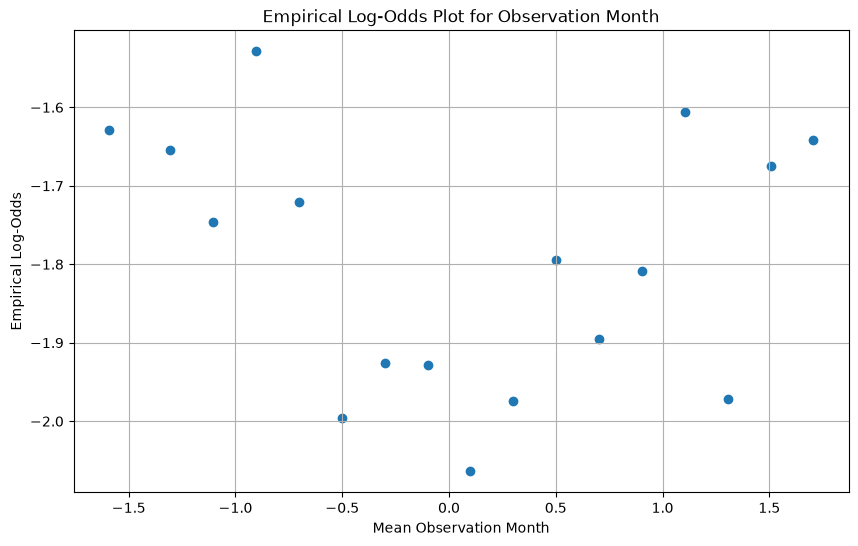

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    observation_month_target_summary['mean_observation_month'],
    observation_month_target_summary['log-odds']
)
plt.title('Empirical Log-Odds Plot for Observation Month')
plt.xlabel('Mean Observation Month')
plt.ylabel('Empirical Log-Odds')    
plt.grid()
plt.show()

Empirical Log-odds plot shows that there is no a straight-line relationship between observation-month feature and purchased target. The relatioship looks like more to U-shape.

#### Spline Plots

In [ ]:
print(X_train['observation_month'].head())
print("_--------------------------------")
print(X_test['observation_month'].head())


2337   -1.103924
7036    1.706369
3668    1.304899
4162    0.501958
676     1.104164
Name: observation_month, dtype: float64
_--------------------------------
1279    1.505634
6711   -1.706129
7365    1.505634
1555    0.100488
6987   -1.103924
Name: observation_month, dtype: float64


1-step: Initializing SplineTransformer. Parameters:
- `n_knots` = controls how many places the spline is allowed to bend/change its behavior. Fewer knots means a smoother, simpler curve; more knots means a more flexible curve.
- `degree` = controls the degree of the polynomial pieces used between knots.

In [ ]:
spline = SplineTransformer(
    n_knots=5,
    degree=3,
    include_bias=True
)

2-step: Transforming the `observation_month` feature with SplineTransformer

In [ ]:
train_observation_month_spline = spline.fit_transform(X_train[['observation_month']])
test_observation_month_spline = spline.transform(X_test[['observation_month']])

3-step: Converting the spline arrays into DataFrames

In [ ]:
observation_month_spline_columns = spline.get_feature_names_out(['observation_month'])

train_observation_month_spline_df = pd.DataFrame(
    train_observation_month_spline,
    columns=observation_month_spline_columns,
    index=X_train.index
)

test_observation_month_spline_df = pd.DataFrame(
    test_observation_month_spline,
    columns=observation_month_spline_columns,
    index=X_test.index
)

In [ ]:
train_observation_month_spline_df.head()

,observation_month_sp_0,observation_month_sp_1,observation_month_sp_2,observation_month_sp_3,observation_month_sp_4,observation_month_sp_5,observation_month_sp_6
2337,0.00424,0.344257,0.592883,0.058620,0.000000,0.000000,0.000000
7036,0.00000,0.000000,0.000000,0.000000,0.166667,0.666667,0.166667
3668,0.00000,0.000000,0.000000,0.017369,0.460581,0.497320,0.024730
4162,0.00000,0.000000,0.011636,0.422417,0.532024,0.033924,0.000000
676,0.00000,0.000000,0.000000,0.058620,0.592883,0.344257,0.004240


In [ ]:
train_observation_month_spline_df.shape

(6015, 7)

In [ ]:
test_observation_month_spline_df.head()

,observation_month_sp_0,observation_month_sp_1,observation_month_sp_2,observation_month_sp_3,observation_month_sp_4,observation_month_sp_5,observation_month_sp_6
1279,0.000000,0.000000,0.000000,0.002171,0.305482,0.617817,0.07453
6711,0.166667,0.666667,0.166667,0.000000,0.000000,0.000000,0.00000
7365,0.000000,0.000000,0.000000,0.002171,0.305482,0.617817,0.07453
1555,0.000000,0.000000,0.114492,0.653640,0.231596,0.000271,0.00000
6987,0.004240,0.344257,0.592883,0.058620,0.000000,0.000000,0.00000


In [ ]:
test_observation_month_spline_df.shape

(1504, 7)

4-step: Combining `X_train` data with `observation_month_spline`

In [ ]:
X_train_without_month = X_train.drop(
    columns=['observation_month']
)

X_test_without_month = X_test.drop(
    columns=['observation_month']
)

In [ ]:
X_train_observation_month_spline = pd.concat(
    [
        X_train_without_month,
        train_observation_month_spline_df
    ],
    axis=1
)

X_test_observation_month_spline = pd.concat(
    [
        X_test_without_month,
        test_observation_month_spline_df
    ],
    axis=1
)

5-step: Training model

In [ ]:
observation_month_spline_model = LogisticRegression(
    max_iter=5000
)

observation_month_spline_model.fit(
    X_train_observation_month_spline,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

Evaluating Model performance

In [ ]:
train_predictions_obsmonth_spline_model = observation_month_spline_model.predict(X_train_observation_month_spline)
test_predictions_obsmonth_spline_model = observation_month_spline_model.predict(X_test_observation_month_spline)

train_obsmonth_spline_TP = np.sum((train_predictions_obsmonth_spline_model == 1) & (y_train == 1))
train_obsmonth_spline_TN = np.sum((train_predictions_obsmonth_spline_model == 0) & (y_train == 0))
train_obsmonth_spline_FP = np.sum((train_predictions_obsmonth_spline_model == 1) & (y_train == 0))
train_obsmonth_spline_FN = np.sum((train_predictions_obsmonth_spline_model == 0) & (y_train == 1))

test_obsmonth_spline_TP = np.sum((test_predictions_obsmonth_spline_model == 1) & (y_test == 1))
test_obsmonth_spline_TN = np.sum((test_predictions_obsmonth_spline_model == 0) & (y_test == 0))
test_obsmonth_spline_FP = np.sum((test_predictions_obsmonth_spline_model == 1) & (y_test == 0))
test_obsmonth_spline_FN = np.sum((test_predictions_obsmonth_spline_model == 0) & (y_test == 1))

confusion_matrix['Observation_month_spline_model'] = [
    train_obsmonth_spline_TP,
    train_obsmonth_spline_TN,
    train_obsmonth_spline_FP,
    train_obsmonth_spline_FN,
    test_obsmonth_spline_TP,
    test_obsmonth_spline_TN,
    test_obsmonth_spline_FP,
    test_obsmonth_spline_FN
]

confusion_matrix

,Ordinary-model,Observation_month_spline_model
Train_TP,77,86
Train_TN,5093,5088
Train_FP,59,64
Train_FN,786,777
Test_TP,22,25
Test_TN,1270,1270
Test_FP,6,6
Test_FN,206,203


In [ ]:
train_accuracy_obsmonth_spline_model = (
    (train_obsmonth_spline_TP + train_obsmonth_spline_TN) / 
    (train_obsmonth_spline_TP + train_obsmonth_spline_TN + train_obsmonth_spline_FP + train_obsmonth_spline_FN))
train_balanced_acc_obsmonth_spline_model = 1/2 * (
    train_obsmonth_spline_TP / (train_obsmonth_spline_TP + train_obsmonth_spline_FN) + 
    train_obsmonth_spline_TN / (train_obsmonth_spline_TN + train_obsmonth_spline_FP))
train_precision_obsmonth_spline_model = train_obsmonth_spline_TP / (train_obsmonth_spline_TP + train_obsmonth_spline_FP)
train_recall_obsmonth_spline_model = train_obsmonth_spline_TP / (train_obsmonth_spline_TP + train_obsmonth_spline_FN)
train_F1_score_obsmonth_spline_model = 2 * (
    (train_precision_obsmonth_spline_model * train_recall_obsmonth_spline_model) /
    (train_precision_obsmonth_spline_model + train_recall_obsmonth_spline_model))

test_accuracy_obsmonth_spline_model = (
    (test_obsmonth_spline_TP + test_obsmonth_spline_TN) /
    (test_obsmonth_spline_TP + test_obsmonth_spline_TN + test_obsmonth_spline_FP + test_obsmonth_spline_FN))
test_balanced_acc_obsmonth_spline_model = 1/2 * (
    test_obsmonth_spline_TP / (test_obsmonth_spline_TP + test_obsmonth_spline_FN) + 
    test_obsmonth_spline_TN / (test_obsmonth_spline_TN + test_obsmonth_spline_FP))
test_precision_obsmonth_spline_model = test_obsmonth_spline_TP / (test_obsmonth_spline_TP + test_obsmonth_spline_TN)
test_recall_obsmonth_spline_model = test_obsmonth_spline_TP / (test_obsmonth_spline_TP + test_obsmonth_spline_FN)
test_F1_score_obsmonth_spline_model = 2 * (
    (test_precision_obsmonth_spline_model * test_recall_obsmonth_spline_model) /
    (test_precision_obsmonth_spline_model + test_recall_obsmonth_spline_model))

models_restuls['Observation_month_spline_model'] = [
    train_accuracy_obsmonth_spline_model,
    train_balanced_acc_obsmonth_spline_model,
    train_precision_obsmonth_spline_model,
    train_recall_obsmonth_spline_model,
    train_F1_score_obsmonth_spline_model,
    test_accuracy_obsmonth_spline_model,
    test_balanced_acc_obsmonth_spline_model,
    test_precision_obsmonth_spline_model,
    test_recall_obsmonth_spline_model,
    test_F1_score_obsmonth_spline_model
]
models_restuls

,Ordinary-model,Observation_month_spline_model
train-accuracy,0.859518,0.860183
train-balanced-accuracy,0.538886,0.543615
train-precision,0.566176,0.573333
train-recall,0.089224,0.099652
train-F1-score,0.154154,0.169793
test-accuracy,0.859043,0.861037
test-balanced-accuracy,0.545895,0.552473
test-precision,0.785714,0.019305
test-recall,0.096491,0.109649
test-F1-score,0.171875,0.032830


plotting the observation-month-spline curve

In [ ]:
# generating evenly spaced observation-months for visualization 
observation_month_grid = np.linspace(
    X_train['observation_month'].min(),
    X_train['observation_month'].max(),
    300
).reshape(-1, 1)

# converting these 300 observation-months into the same spline basis features that were used during training
observation_month_grid_spline = spline.transform(
    observation_month_grid
)

# convert spline output to DataFrame
observation_month_grid_spline_df = pd.DataFrame(
    observation_month_grid_spline,
    columns=observation_month_spline_columns
)

c:\Users\k\anaconda3\envs\creditrisk\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SplineTransformer was fitted with feature names
  warnings.warn(


In [ ]:
# Asking the fitted logistic regression model for the log-odds at each of these observation months
# A common partial-effect approach is to hold them at their training means:
other_features_mean = X_train_without_month.mean()

X_grid_other = pd.DataFrame(
    np.tile(
        other_features_mean.values,
        (300, 1)
    ),
    columns=X_train_without_month.columns
)

# comnining them
X_grid = pd.concat(
    [
        X_grid_other,
        observation_month_grid_spline_df
    ],
    axis=1
)

X_grid = X_grid[
    X_train_observation_month_spline.columns
]

observation_month_spline_log_odds = (
    observation_month_spline_model.decision_function(
        X_grid
    )
)

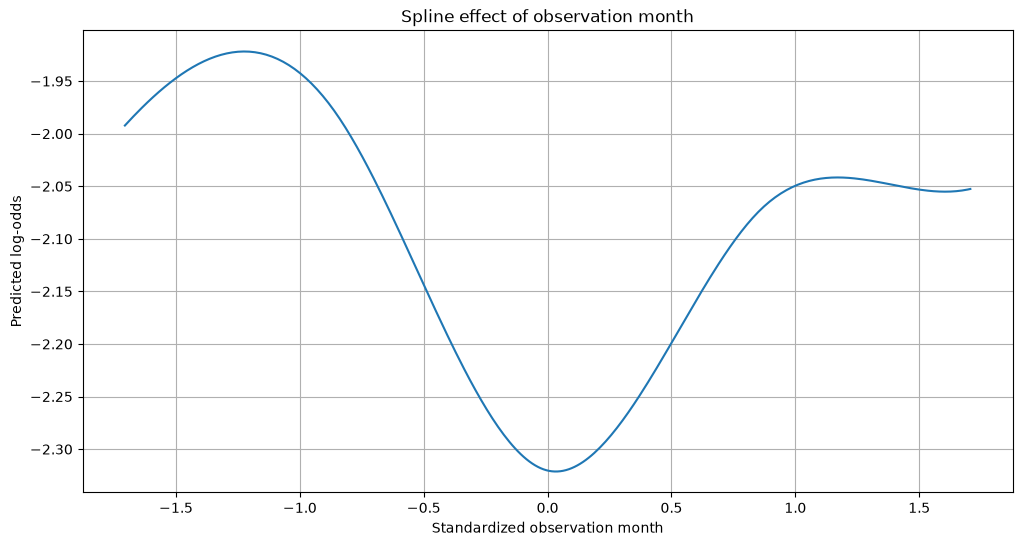

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    observation_month_grid.ravel(),
    observation_month_spline_log_odds
)

plt.xlabel('Standardized observation month')
plt.ylabel('Predicted log-odds')
plt.title('Spline effect of observation month')
plt.grid()

plt.show()

### age feature

In [ ]:
age = X_train[['age']]
age_with_purchase = pd.concat([age, y_train], axis=1)
age_with_purchase.head()

,age,purchased
2337,1.103772,0
7036,-1.810264,0
3668,1.103772,0
4162,-1.724557,0
676,0.846651,0


#### Empirical Log-Odds plots

1-step: Dividing the feature (age) into bins

In [ ]:
age_with_purchase['age_bins'] = pd.qcut(
    age_with_purchase['age'],
    q=20,
    duplicates='drop'
)
age_with_purchase.head()

,age,purchased,age_bins
2337,1.103772,0,"(0.847, 1.104]"
7036,-1.810264,0,"(-1.811, -1.725]"
3668,1.103772,0,"(0.847, 1.104]"
4162,-1.724557,0,"(-1.811, -1.725]"
676,0.846651,0,"(0.675, 0.847]"


2-step: Within each bin, calculate 
- a represenative feature value, usually the mean of the feature
- the mean of the binary target

In [ ]:
age_with_purchase_summary = age_with_purchase.groupby(
    by='age_bins'
).agg(
    mean_age=('age', 'mean'),
    purchased_mean=('purchased', 'mean')
)

age_with_purchase_summary

,mean_age,purchased_mean
age_bins,,
"(-1.811, -1.725]",-1.794083,0.056047
"(-1.725, -1.382]",-1.479258,0.051724
"(-1.382, -1.125]",-1.204739,0.095890
"(-1.125, -0.867]",-0.955374,0.121469
"(-0.867, -0.696]",-0.741348,0.126246
"(-0.696, -0.525]",-0.563216,0.140401
"(-0.525, -0.439]",-0.438953,0.142857
"(-0.439, -0.268]",-0.307821,0.160000
"(-0.268, -0.182]",-0.181832,0.175676


3-step: Converting the probability into empirical log-oods

In [ ]:
age_with_purchase_summary['log_odds'] = np.log(
    age_with_purchase_summary['purchased_mean'] / (1 - age_with_purchase_summary['purchased_mean'])
)

age_with_purchase_summary

,mean_age,purchased_mean,log_odds
age_bins,,,
"(-1.811, -1.725]",-1.794083,0.056047,-2.823882
"(-1.725, -1.382]",-1.479258,0.051724,-2.908721
"(-1.382, -1.125]",-1.204739,0.095890,-2.243745
"(-1.125, -0.867]",-0.955374,0.121469,-1.978593
"(-0.867, -0.696]",-0.741348,0.126246,-1.934568
"(-0.696, -0.525]",-0.563216,0.140401,-1.811962
"(-0.525, -0.439]",-0.438953,0.142857,-1.791759
"(-0.439, -0.268]",-0.307821,0.160000,-1.658228
"(-0.268, -0.182]",-0.181832,0.175676,-1.545925


4-step: Plotting representative feature value and empirical log-odds

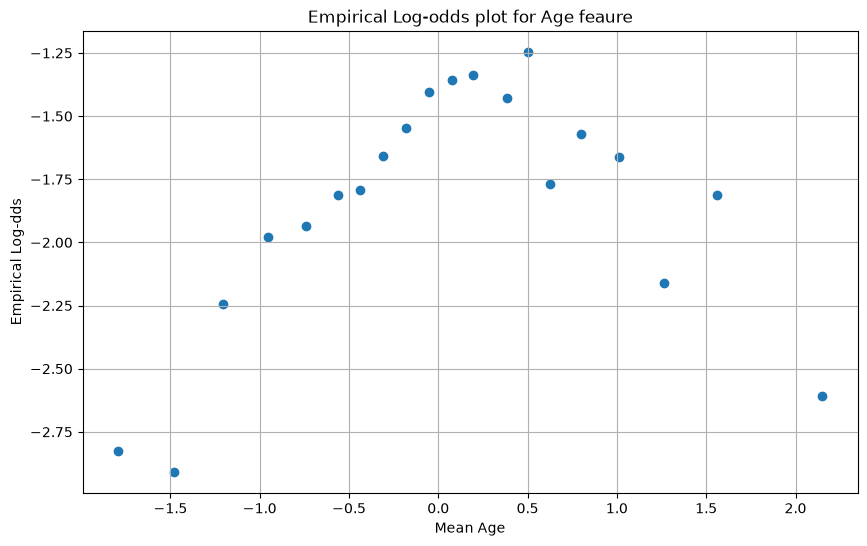

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    age_with_purchase_summary['mean_age'],
    age_with_purchase_summary['log_odds']
)
plt.title("Empirical Log-odds plot for Age feaure")
plt.xlabel("Mean Age")
plt.ylabel('Empirical Log-dds')
plt.grid()
plt.show()

#### Polynomial Term

In [ ]:
X_train_observation_month_spline.head()

,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,education_level,noise_feature_1,noise_feature_2,noise_feature_3,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,marketing_channel_Email,marketing_channel_Organic,marketing_channel_Partner_Rare,marketing_channel_Referral,marketing_channel_Search,marketing_channel_Social,observation_month_sp_0,observation_month_sp_1,observation_month_sp_2,observation_month_sp_3,observation_month_sp_4,observation_month_sp_5,observation_month_sp_6
2337,1.103772,-0.567079,-0.573305,0.659082,0.839731,-0.268099,0.503769,0.212627,-0.615486,-0.769941,-0.863334,-1.444251,-1.671079,-0.289367,0.018235,0.344041,-0.107967,0.016959,0.570968,-1.004866,0.862580,-0.402631,-0.519059,2.042228,-0.544371,-0.491891,-0.746309,-0.467135,-0.384375,-0.566920,-0.146498,-0.402184,-0.491891,2.194201,0.00424,0.344257,0.592883,0.058620,0.000000,0.000000,0.000000
7036,-1.810264,-0.444706,-0.437420,0.659082,0.729723,0.646001,0.411539,-0.891475,-0.615486,-0.388528,-0.264109,-0.355515,-1.281653,-0.289367,1.403156,-0.690353,-1.240187,-1.277112,-1.235987,0.995025,0.862580,-0.402631,-0.519059,-0.489596,-0.544371,-0.491891,-0.746309,-0.467135,-0.384375,-0.566920,-0.146498,-0.402184,2.032701,-0.455686,0.00000,0.000000,0.000000,0.000000,0.166667,0.666667,0.166667
3668,1.103772,-1.287413,-1.286570,-0.648474,-0.480371,1.753129,1.856050,-0.891475,1.624515,-0.993395,1.533568,0.188853,1.054906,0.564539,0.018235,-1.035151,-1.240187,0.294028,0.283773,-1.004866,-1.159159,-0.402631,-0.519059,-0.489596,-0.544371,2.032701,-0.746309,-0.467135,-0.384375,1.763682,-0.146498,-0.402184,-0.491891,-0.455686,0.00000,0.000000,0.000000,0.017369,0.460581,0.497320,0.024730
4162,-1.724557,-1.161460,-1.159294,-0.321585,-0.150345,-0.837904,-0.584810,-0.891475,1.624515,-0.608130,0.335117,0.461037,-0.502800,-0.289367,2.095616,1.033638,2.156474,-1.664117,-0.696913,0.995025,0.862580,-0.402631,-0.519059,-0.489596,-0.544371,2.032701,-0.746309,2.140426,-0.384375,-0.566920,-0.146498,2.486091,-0.491891,-0.455686,0.00000,0.000000,0.011636,0.422417,0.532024,0.033924,0.000000
676,0.846651,0.689436,0.702941,-0.321585,-0.480371,0.047428,-1.407090,1.316728,-0.615486,0.374298,-0.264109,-0.355515,-1.281653,-0.289367,0.018235,0.688839,-0.107967,-1.100648,-0.939444,-1.004866,0.862580,-0.402631,1.926307,-0.489596,-0.544371,-0.491891,-0.746309,-0.467135,-0.384375,-0.566920,-0.146498,-0.402184,2.032701,-0.455686,0.00000,0.000000,0.000000,0.058620,0.592883,0.344257,0.004240


In [ ]:
X_train_observation_month_spline.shape

(6015, 41)

adding polnomial features

In [ ]:
X_train_age_poly = X_train_observation_month_spline.copy()
X_test_age_poly = X_test_observation_month_spline.copy()


X_train_age_poly['age_squared'] = X_train_age_poly['age'] ** 2
X_test_age_poly['age_squared'] = X_test_age_poly['age'] ** 2



training model

In [ ]:
model_age_poly = LogisticRegression(
    max_iter=5000
)

model_age_poly.fit(
    X_train_age_poly,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

evaluating Model performance

In [ ]:
# making predictions
train_predictions_model_agePoly = model_age_poly.predict(X_train_age_poly)
test_predictions_model_agePoly = model_age_poly.predict(X_test_age_poly)


# Confusion matirx
# Training data
TP_train_model_agePoly = np.sum((train_predictions_model_agePoly == 1) & (y_train == 1))
TN_train_model_agePoly = np.sum((train_predictions_model_agePoly == 0) & (y_train == 0))
FP_train_model_agePoly = np.sum((train_predictions_model_agePoly == 1) & (y_train == 0))
FN_train_model_agePoly = np.sum((train_predictions_model_agePoly == 0) & (y_train == 1))
# test data
TP_test_model_agePoly = np.sum((test_predictions_model_agePoly == 1) & (y_test == 1))
TN_test_model_agePoly = np.sum((test_predictions_model_agePoly == 0) & (y_test == 0))
FP_test_model_agePoly = np.sum((test_predictions_model_agePoly == 1) & (y_test == 0))
FN_test_model_agePoly = np.sum((test_predictions_model_agePoly == 0) & (y_test == 1))

confusion_matrix['age_polynomial_feature_model'] = [
    TP_train_model_agePoly,
    TN_train_model_agePoly,
    FP_train_model_agePoly,
    FN_train_model_agePoly,
    TP_test_model_agePoly,
    TN_test_model_agePoly,
    FP_test_model_agePoly,
    FN_test_model_agePoly
]

confusion_matrix

,Ordinary-model,Observation_month_spline_model,age_polynomial_feature_model
Train_TP,77,86,116
Train_TN,5093,5088,5075
Train_FP,59,64,77
Train_FN,786,777,747
Test_TP,22,25,32
Test_TN,1270,1270,1269
Test_FP,6,6,7
Test_FN,206,203,196


In [ ]:
train_accuracy_model_agePoly = (
    (TP_train_model_agePoly + TN_train_model_agePoly) / 
    (TP_train_model_agePoly + TN_train_model_agePoly + FP_train_model_agePoly + FN_train_model_agePoly)
)
train_balanced_acc_model_agePoly = 1/2 * (
    TP_train_model_agePoly / (TP_train_model_agePoly + FN_train_model_agePoly) + 
    TN_train_model_agePoly / (TN_train_model_agePoly + FP_train_model_agePoly)
)
train_precision_model_agePoly = TP_train_model_agePoly / (TP_train_model_agePoly + FP_train_model_agePoly)
train_recall_model_agePoly = TP_train_model_agePoly / (TP_train_model_agePoly + FN_train_model_agePoly)
train_F1_score_model_agePoly = 2 * (
    (train_precision_model_agePoly * train_recall_model_agePoly) /
    (train_precision_model_agePoly + train_recall_model_agePoly)
)

test_accuracy_model_agePoly = (
    (TP_test_model_agePoly + TN_test_model_agePoly) / 
    (TP_test_model_agePoly + TN_test_model_agePoly + FP_test_model_agePoly + FN_test_model_agePoly)
)
test_balanced_acc_model_agePoly = 1/2 * (
    TP_test_model_agePoly / (TP_test_model_agePoly + FN_test_model_agePoly) + 
    TN_test_model_agePoly / (TN_test_model_agePoly + FP_test_model_agePoly)
)
test_precision_model_agePoly = TP_test_model_agePoly / (TP_test_model_agePoly + FP_test_model_agePoly)
test_recall_model_agePoly = TP_test_model_agePoly / (TP_test_model_agePoly + FN_test_model_agePoly)
test_F1_score_model_agePoly = 2 * (
    (test_precision_model_agePoly * test_recall_model_agePoly) /
    (test_precision_model_agePoly + test_recall_model_agePoly)
)

models_restuls['age_polynomial_feature_model'] = [
    train_accuracy_model_agePoly,
    train_balanced_acc_model_agePoly,
    train_precision_model_agePoly,
    train_recall_model_agePoly,
    train_F1_score_model_agePoly,
    test_accuracy_model_agePoly,
    test_balanced_acc_model_agePoly,
    test_precision_model_agePoly,
    test_recall_model_agePoly,
    test_F1_score_model_agePoly
]
models_restuls

,Ordinary-model,Observation_month_spline_model,age_polynomial_feature_model
train-accuracy,0.859518,0.860183,0.863009
train-balanced-accuracy,0.538886,0.543615,0.559735
train-precision,0.566176,0.573333,0.601036
train-recall,0.089224,0.099652,0.134415
train-F1-score,0.154154,0.169793,0.219697
test-accuracy,0.859043,0.861037,0.865027
test-balanced-accuracy,0.545895,0.552473,0.567432
test-precision,0.785714,0.019305,0.820513
test-recall,0.096491,0.109649,0.140351
test-F1-score,0.171875,0.032830,0.239700


plotting model's decision function for polynomial age feature

In [ ]:
age_grid = np.linspace(
    X_train_age_poly['age'].min(),
    X_train_age_poly['age'].max(),
    300
)

X_grid_poly = pd.DataFrame(
    np.tile(
        X_train_age_poly.mean().values,
        (300, 1)
    ),
    columns=X_train_age_poly.columns
)

X_grid_poly['age'] = age_grid

# use EXACT column name from training
X_grid_poly['age_squared'] = age_grid ** 2

poly_log_odds = model_age_poly.decision_function(
    X_grid_poly
)

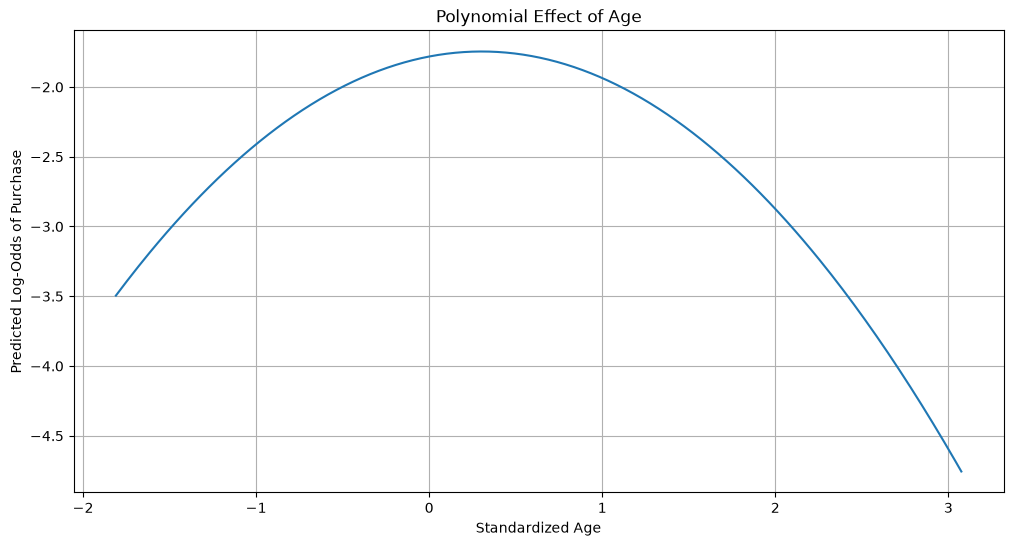

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    age_grid,
    poly_log_odds,
    label='Polynomial Logistic Regression'
)

plt.xlabel('Standardized Age')
plt.ylabel('Predicted Log-Odds of Purchase')
plt.title('Polynomial Effect of Age')
plt.grid()

plt.show()

In [ ]:
X_train_age_grid = np.linspace(
    X_train_age_poly['age'].min(),
    X_train_age_poly['age'].max(),
    6015
)
X_train_age_poly_odds = model_age_poly.decision_function(
    X_train_age_poly
)


### Other continuous features

In [ ]:
left_continuous_features = [
    'monthly_income',
    'annual_income',
    'website_visits_30d',
    'website_visits_90d',
    'session_minutes',
    'discount_pct',
    'support_tickets_30d',
    'days_since_last_purchase',
    'cart_items',
    'email_opens_30d',
    'profile_views_30d',
    'social_referrals_30d',
    'survey_score',
    'preferred_contact_hour',
    'noise_feature_1',
    'noise_feature_2'
]

In [ ]:
left_features_df = pd.concat([X_train[left_continuous_features], y_train], axis=1)
left_features_df.head()

,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,noise_feature_1,noise_feature_2,purchased
2337,-0.567079,-0.573305,0.659082,0.839731,-0.268099,0.503769,0.212627,-0.769941,-0.863334,-1.444251,-1.671079,-0.289367,0.018235,0.344041,0.016959,0.570968,0
7036,-0.444706,-0.437420,0.659082,0.729723,0.646001,0.411539,-0.891475,-0.388528,-0.264109,-0.355515,-1.281653,-0.289367,1.403156,-0.690353,-1.277112,-1.235987,0
3668,-1.287413,-1.286570,-0.648474,-0.480371,1.753129,1.856050,-0.891475,-0.993395,1.533568,0.188853,1.054906,0.564539,0.018235,-1.035151,0.294028,0.283773,0
4162,-1.161460,-1.159294,-0.321585,-0.150345,-0.837904,-0.584810,-0.891475,-0.608130,0.335117,0.461037,-0.502800,-0.289367,2.095616,1.033638,-1.664117,-0.696913,0
676,0.689436,0.702941,-0.321585,-0.480371,0.047428,-1.407090,1.316728,0.374298,-0.264109,-0.355515,-1.281653,-0.289367,0.018235,0.688839,-1.100648,-0.939444,0


#### Empirical Log-odds plotting

In [ ]:
def empirical_log_odds_plotting(df, feature_name, target):

    data = df[[feature_name, target]].copy()

    # 1. Divide feature into bins
    data['bins'] = pd.qcut(
        data[feature_name],
        q=20,
        duplicates='drop'
    )

    # 2. Feature mean and target probability within each bin
    summary = data.groupby(
        'bins',
        observed=True
    ).agg(
        feature_mean=(feature_name, 'mean'),
        target_mean=(target, 'mean')
    )

    # Prevent log(0) or division by zero
    p = summary['target_mean'].clip(
        1e-6,
        1 - 1e-6
    )

    # 3. Probability -> log-odds
    summary['log_odds'] = np.log(
        p / (1 - p)
    )

    # 4. Plot
    plt.figure(figsize=(10, 6))

    plt.scatter(
        summary['feature_mean'],
        summary['log_odds']
    )

    plt.title(
        f"Empirical Log-Odds Plot for {feature_name}"
    )
    plt.xlabel(f"Mean {feature_name}")
    plt.ylabel("Empirical Log-Odds")
    plt.grid()

    plt.show()

In [ ]:
left_features_df.head()

,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,noise_feature_1,noise_feature_2,purchased
2337,-0.567079,-0.573305,0.659082,0.839731,-0.268099,0.503769,0.212627,-0.769941,-0.863334,-1.444251,-1.671079,-0.289367,0.018235,0.344041,0.016959,0.570968,0
7036,-0.444706,-0.437420,0.659082,0.729723,0.646001,0.411539,-0.891475,-0.388528,-0.264109,-0.355515,-1.281653,-0.289367,1.403156,-0.690353,-1.277112,-1.235987,0
3668,-1.287413,-1.286570,-0.648474,-0.480371,1.753129,1.856050,-0.891475,-0.993395,1.533568,0.188853,1.054906,0.564539,0.018235,-1.035151,0.294028,0.283773,0
4162,-1.161460,-1.159294,-0.321585,-0.150345,-0.837904,-0.584810,-0.891475,-0.608130,0.335117,0.461037,-0.502800,-0.289367,2.095616,1.033638,-1.664117,-0.696913,0
676,0.689436,0.702941,-0.321585,-0.480371,0.047428,-1.407090,1.316728,0.374298,-0.264109,-0.355515,-1.281653,-0.289367,0.018235,0.688839,-1.100648,-0.939444,0


plotting Empirical log-odds

In [ ]:
# for feature in left_features_df.columns:
#     if feature != 'purchased':
#         empirical_log_odds_plotting(left_features_df, feature, 'purchased')


we can see that these features: 
- these `website_visits_30d1`, `website_visits_90d`, `discount_pct`, `days_since_last_purchase`, `cart_items`, `email_opens_30d`, `profile_views_30d`, `survey_score` features have clear straight linear relationship. I keep them as they are. 
- these `monthly_income`, `annual_income`, `session_minutes`,`support_tickets_30d`, `social_referrals_30d`,`preferred_contact_hour`,`noise_feature_1`, `noise_feature_2` features have curved, noice or non-linear relationships

In [ ]:
smooth_features = [
    'monthly_income',
    'annual_income',
    'session_minutes',
    'support_tickets_30d',
    'social_referrals_30d',
    'preferred_contact_hour',
    'noise_feature_1',
    'noise_feature_2'
]


#### GAM 

In [ ]:
X_train_age_poly.shape

(6015, 42)

In [ ]:
X_test_age_poly.shape

(1504, 42)

In [ ]:
X_train_age_poly.head()

,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,education_level,noise_feature_1,noise_feature_2,noise_feature_3,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,marketing_channel_Email,marketing_channel_Organic,marketing_channel_Partner_Rare,marketing_channel_Referral,marketing_channel_Search,marketing_channel_Social,observation_month_sp_0,observation_month_sp_1,observation_month_sp_2,observation_month_sp_3,observation_month_sp_4,observation_month_sp_5,observation_month_sp_6,age_squared
2337,1.103772,-0.567079,-0.573305,0.659082,0.839731,-0.268099,0.503769,0.212627,-0.615486,-0.769941,-0.863334,-1.444251,-1.671079,-0.289367,0.018235,0.344041,-0.107967,0.016959,0.570968,-1.004866,0.862580,-0.402631,-0.519059,2.042228,-0.544371,-0.491891,-0.746309,-0.467135,-0.384375,-0.566920,-0.146498,-0.402184,-0.491891,2.194201,0.00424,0.344257,0.592883,0.058620,0.000000,0.000000,0.000000,1.218312
7036,-1.810264,-0.444706,-0.437420,0.659082,0.729723,0.646001,0.411539,-0.891475,-0.615486,-0.388528,-0.264109,-0.355515,-1.281653,-0.289367,1.403156,-0.690353,-1.240187,-1.277112,-1.235987,0.995025,0.862580,-0.402631,-0.519059,-0.489596,-0.544371,-0.491891,-0.746309,-0.467135,-0.384375,-0.566920,-0.146498,-0.402184,2.032701,-0.455686,0.00000,0.000000,0.000000,0.000000,0.166667,0.666667,0.166667,3.277056
3668,1.103772,-1.287413,-1.286570,-0.648474,-0.480371,1.753129,1.856050,-0.891475,1.624515,-0.993395,1.533568,0.188853,1.054906,0.564539,0.018235,-1.035151,-1.240187,0.294028,0.283773,-1.004866,-1.159159,-0.402631,-0.519059,-0.489596,-0.544371,2.032701,-0.746309,-0.467135,-0.384375,1.763682,-0.146498,-0.402184,-0.491891,-0.455686,0.00000,0.000000,0.000000,0.017369,0.460581,0.497320,0.024730,1.218312
4162,-1.724557,-1.161460,-1.159294,-0.321585,-0.150345,-0.837904,-0.584810,-0.891475,1.624515,-0.608130,0.335117,0.461037,-0.502800,-0.289367,2.095616,1.033638,2.156474,-1.664117,-0.696913,0.995025,0.862580,-0.402631,-0.519059,-0.489596,-0.544371,2.032701,-0.746309,2.140426,-0.384375,-0.566920,-0.146498,2.486091,-0.491891,-0.455686,0.00000,0.000000,0.011636,0.422417,0.532024,0.033924,0.000000,2.974097
676,0.846651,0.689436,0.702941,-0.321585,-0.480371,0.047428,-1.407090,1.316728,-0.615486,0.374298,-0.264109,-0.355515,-1.281653,-0.289367,0.018235,0.688839,-0.107967,-1.100648,-0.939444,-1.004866,0.862580,-0.402631,1.926307,-0.489596,-0.544371,-0.491891,-0.746309,-0.467135,-0.384375,-0.566920,-0.146498,-0.402184,2.032701,-0.455686,0.00000,0.000000,0.000000,0.058620,0.592883,0.344257,0.004240,0.716818


In [ ]:
X_train_age_poly.columns

Index(['age', 'monthly_income', 'annual_income', 'website_visits_30d',
       'website_visits_90d', 'session_minutes', 'discount_pct',
       'support_tickets_30d', 'premium_member', 'days_since_last_purchase',
       'cart_items', 'email_opens_30d', 'profile_views_30d',
       'social_referrals_30d', 'survey_score', 'preferred_contact_hour',
       'education_level', 'noise_feature_1', 'noise_feature_2',
       'noise_feature_3', 'device_type_Mobile', 'device_type_Tablet',
       'region_East', 'region_North', 'region_South', 'region_West',
       'app_theme_Light', 'app_theme_System', 'marketing_channel_Email',
       'marketing_channel_Organic', 'marketing_channel_Partner_Rare',
       'marketing_channel_Referral', 'marketing_channel_Search',
       'marketing_channel_Social', 'observation_month_sp_0',
       'observation_month_sp_1', 'observation_month_sp_2',
       'observation_month_sp_3', 'observation_month_sp_4',
       'observation_month_sp_5', 'observation_month_sp_6', 'age_s

In [95]:
X_train_final = X_train_age_poly.copy()

X_test_final = X_test_age_poly[
    X_train_final.columns
].copy()


In [96]:
terms = None

for i, feature in enumerate(X_train_final.columns):

    if feature in smooth_features:
        term = s(i)

    elif feature == 'preferred_contact_hour':
        term = s(i, basis='cp')

    else:
        term = l(i)

    if terms is None:
        terms = term
    else:
        terms = terms + term

In [97]:
terms

l(0) + s(1) + s(2) + l(3) + l(4) + s(5) + l(6) + s(7) + l(8) + l(9) + l(10) + l(11) + l(12) + s(13) + l(14) + s(15) + l(16) + s(17) + s(18) + l(19) + l(20) + l(21) + l(22) + l(23) + l(24) + l(25) + l(26) + l(27) + l(28) + l(29) + l(30) + l(31) + l(32) + l(33) + l(34) + l(35) + l(36) + l(37) + l(38) + l(39) + l(40) + l(41)

In [98]:
gam_model = LogisticGAM(
    terms
)

gam_model.fit(
    X_train_final.values,
    y_train.values
)

LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=100, 
   terms=l(0) + s(1) + s(2) + l(3) + l(4) + s(5) + l(6) + s(7) + l(8) + l(9) + l(10) + l(11) + l(12) + s(13) + l(14) + s(15) + l(16) + s(17) + s(18) + l(19) + l(20) + l(21) + l(22) + l(23) + l(24) + l(25) + l(26) + l(27) + l(28) + l(29) + l(30) + l(31) + l(32) + l(33) + l(34) + l(35) + l(36) + l(37) + l(38) + l(39) + l(40) + l(41) + intercept,
   tol=0.0001, verbose=False)